# Assessing Professor Effectiveness

A reproducible analysis of 89,893 RateMyProfessor records (NYU DS-GA 1001 capstone, group **CAP 85**).
Every result below comes from the tested [`ape`](../src/ape) package — this notebook is a thin
narrative over it. For the full write-up with methodology notes, see the
[project website](https://deepanshumody.github.io/Analysis_RMP_Ratings).

**Preprocessing:** keep professors with ≥ 10 ratings (reliable averages); a high-confidence gender
filter for gender questions; tags normalized per number of ratings; significance threshold
**α = 0.005**; all randomness seeded.

In [1]:
import matplotlib.pyplot as plt
from IPython.display import display

from ape import data, questions


def show(figs, *keys):
    """Display only the named figures so the inline backend doesn't leak the rest."""
    for k, f in figs.items():
        if k not in keys:
            plt.close(f)
    for k in keys:
        display(figs[k])
    plt.close("all")


num = data.load_numeric()
print(f"professors: {len(num):,}")
print(f"with >= 10 ratings: {len(data.filter_min_ratings(num)):,}")
print(f"...and confident gender: {len(data.gender_subset(data.filter_min_ratings(num))):,}")

professors: 89,893
with >= 10 ratings: 9,841
...and confident gender: 7,105


## Q1 — Is there a pro-male bias in average rating?
One-sided Mann–Whitney (directional claim) + KS test.

{'n_male': 3987, 'n_female': 3118, 'male_mean': 3.9641835966892396, 'female_mean': 3.888774855676716, 'mwu_p_one_sided_greater': 0.0003652364707130215, 'mwu_p_two_sided': 0.000730472941426043, 'ks_p': 0.0027717214563375667, 'significant_pro_male': True}


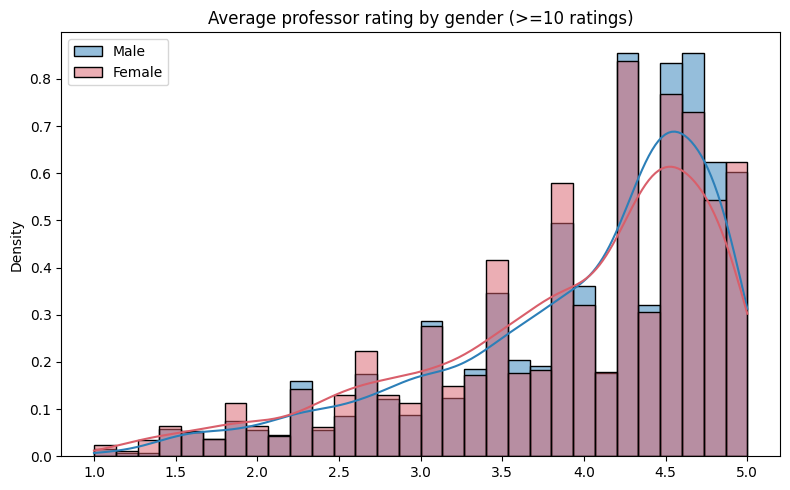

In [2]:
res, figs = questions.q1()
print(res)
show(figs, "q1_rating_by_gender")

Men average ~3.96 vs women ~3.89 — a small but statistically significant pro-male gap.

## Q2 — Is the *spread* of ratings different by gender?

In [3]:
res, _ = questions.q2()
print(res)
plt.close("all")

{'male_var': 0.7349135518332222, 'female_var': 0.8070924350172233, 'levene_stat': 9.24049619037024, 'levene_p': 0.00237582758359149, 'significant': True}


Women's ratings are more dispersed (Levene *p* ≈ 0.002).

## Q3 — Effect sizes (95% CIs)

{'cohen_d': 0.08612728608377464, 'cohen_d_ci': [np.float64(0.03903253665814777), np.float64(0.13310180081873965)], 'variance_ratio': 0.9105692482640345, 'variance_ratio_ci': [np.float64(0.8487020970275647), np.float64(0.9803206384788218)]}


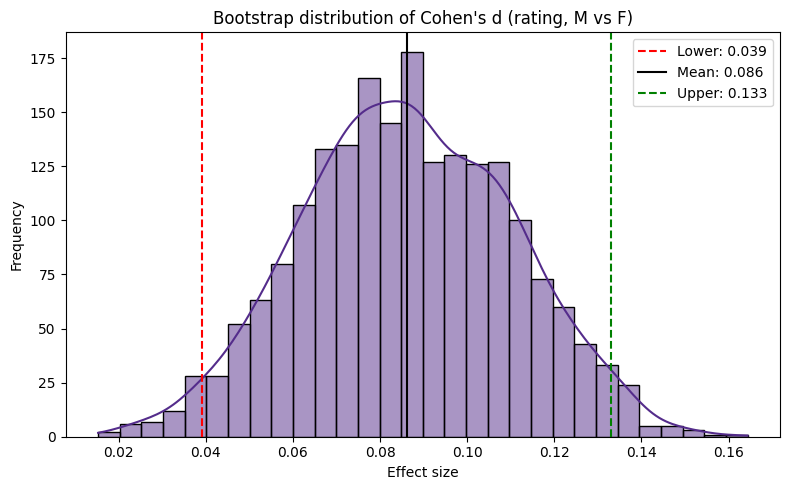

In [4]:
res, figs = questions.q3()
print(res)
show(figs, "q3_effect_size")

Cohen's *d* ≈ 0.09 (CI excludes 0 but small); variance ratio ≈ 0.91.

## Q4 — Which tags differ by gender? (FDR-corrected)

{'n_significant_fdr': 17, 'significant_tags': ['hilarious', 'caring', 'amazing_lectures', 'participation_matters', 'respected', 'group_projects', 'extra_credit', 'graded_by_few', 'good_feedback', 'so_many_papers', 'lots_to_read', 'test_heavy', 'lecture_heavy', 'lots_of_homework', 'inspirational', 'dont_skip', 'clear_grading'], 'most_gendered': ['hilarious', 'caring', 'amazing_lectures'], 'least_gendered': ['tough_grader', 'accessible', 'pop_quizzes']}


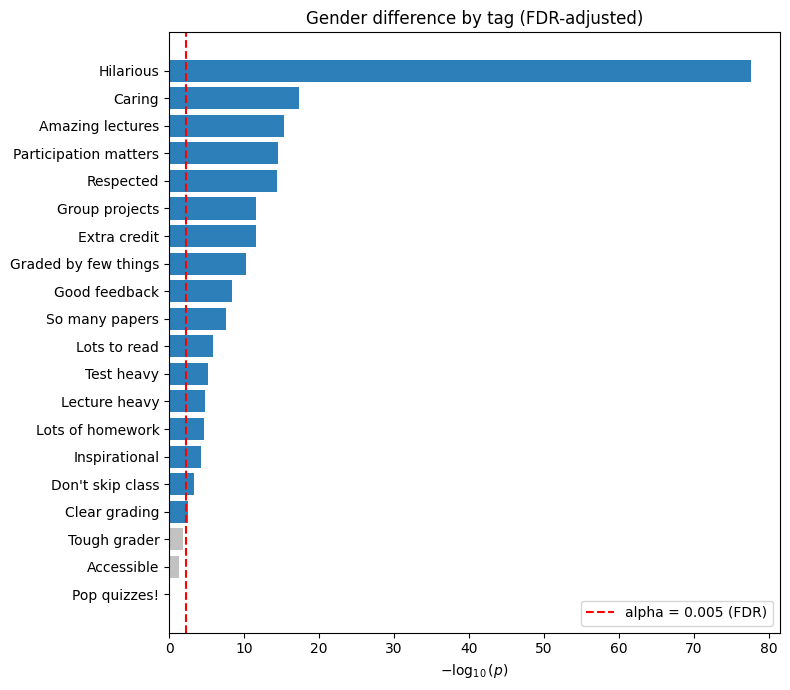

In [5]:
res, figs = questions.q4()
print(res)
show(figs, "q4_tag_significance")

17 of 20 tags are gendered after Benjamini–Hochberg FDR. *Hilarious* is by far the most gendered.

## Q5 / Q6 — Difficulty by gender, and its effect size

Q5: {'male_mean': 2.940030097817908, 'female_mean': 2.9469852469531754, 'mwu_p': 0.7855271637343776, 'ks_p': 0.9969658149637703, 'significant': False}
Q6: {'cohen_d': -0.009056899369025465, 'cohen_d_ci': [np.float64(-0.05758922258495265), np.float64(0.039395766430572174)]}


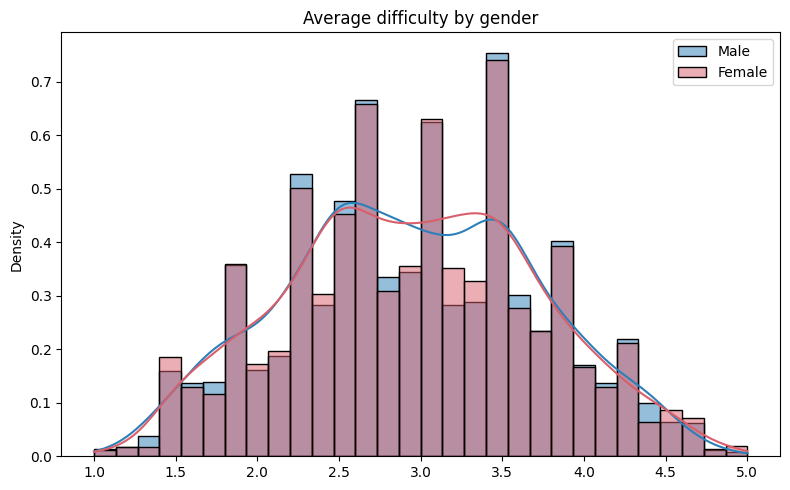

In [6]:
res5, figs5 = questions.q5()
res6, _ = questions.q6()
print("Q5:", res5)
print("Q6:", res6)
show(figs5, "q5_difficulty_by_gender")

No difference in difficulty (MWU *p* ≈ 0.79; *d* ≈ 0).

## Q7 — Predict average rating from numeric predictors
Leak-free k-fold CV + forward selection; from-scratch OLS.

{'best_features': ['prop_retake', 'avg_difficulty', 'received_pepper', 'high_conf_female'], 'best_rmse': 0.3563299980450193, 'best_r2': 0.8098744928545412, 'top_predictor': 'prop_retake', 'top_predictor_beta': 0.5805580915774323, 'forward_path': [('prop_retake', 0.767), ('avg_difficulty', 0.798), ('received_pepper', 0.81), ('high_conf_female', 0.81), ('num_ratings', 0.81), ('prop_online', 0.81)]}


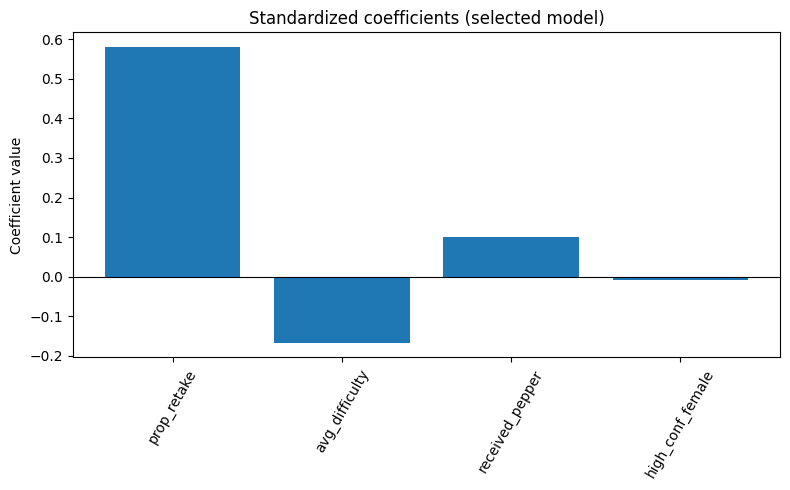

In [7]:
res, figs = questions.q7()
print(res)
show(figs, "q7_coefficients")

R² ≈ 0.81; "proportion who would retake" dominates.

## Q8 / Q9 — Tag-based models for rating and difficulty

Q8: {'best_features': ['tough_grader', 'respected', 'good_feedback', 'amazing_lectures', 'caring', 'hilarious', 'clear_grading', 'extra_credit'], 'best_rmse': 0.4479118493174516, 'best_r2': 0.7438225996564445, 'top_predictor': 'tough_grader', 'top_predictor_beta': -0.24547404616299273, 'forward_path': [('tough_grader', 0.471), ('respected', 0.562), ('good_feedback', 0.627), ('amazing_lectures', 0.678), ('caring', 0.702), ('hilarious', 0.719), ('clear_grading', 0.735), ('extra_credit', 0.744)]}


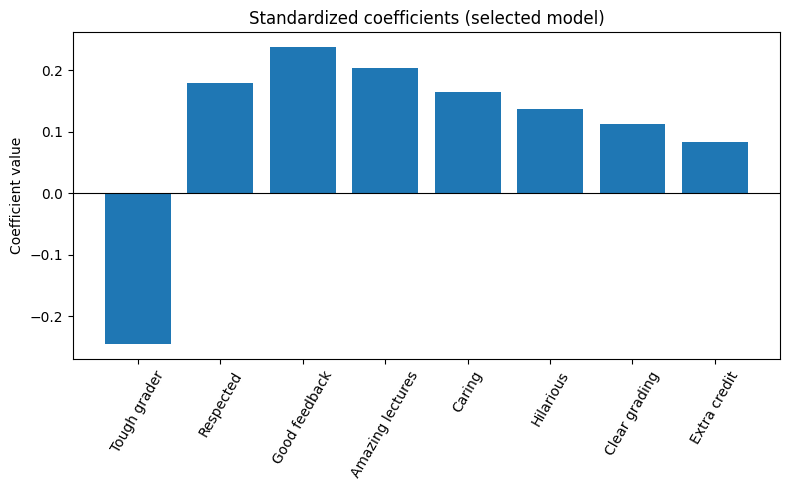

In [8]:
res8, figs8 = questions.q8()
print("Q8:", res8)
show(figs8, "q8_coefficients")

Q9: {'best_features': ['tough_grader', 'test_heavy', 'lots_of_homework', 'lots_to_read', 'accessible', 'dont_skip', 'clear_grading', 'hilarious'], 'best_rmse': 0.47922827667219287, 'best_r2': 0.6002715309404347, 'top_predictor': 'tough_grader', 'top_predictor_beta': 0.40140657897480914, 'forward_path': [('tough_grader', 0.492), ('test_heavy', 0.52), ('lots_of_homework', 0.539), ('lots_to_read', 0.555), ('accessible', 0.572), ('dont_skip', 0.585), ('clear_grading', 0.594), ('hilarious', 0.6)]}


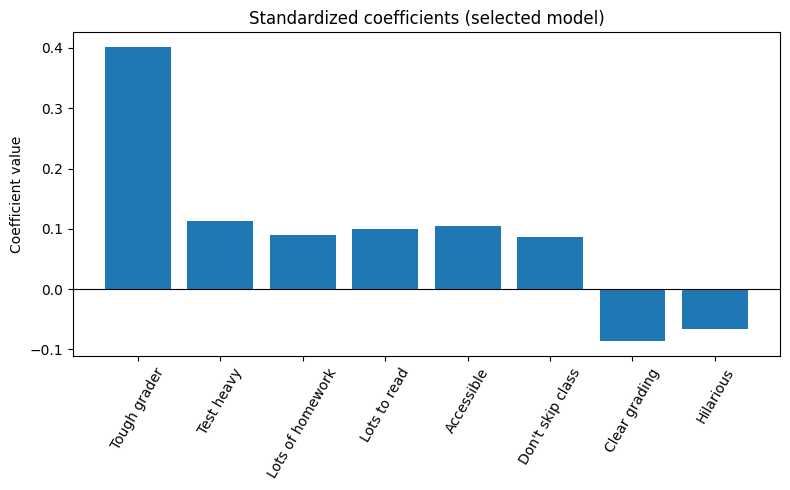

In [9]:
res9, figs9 = questions.q9()
print("Q9:", res9)
show(figs9, "q9_coefficients")

*Tough grader* is the strongest tag both times — negative for rating, positive for difficulty.

## Q10 — Predict "received a pepper"
Leak-free pipeline, balanced classes, Youden-J threshold.

{'n': 5963, 'pepper_rate': 0.5027670635586114, 'auc': 0.8051349072512648, 'threshold': 0.4732747359310517, 'f1_class0': 0.7237076648841355, 'f1_class1': 0.754746835443038, 'confusion': [[406, 187], [123, 477]]}


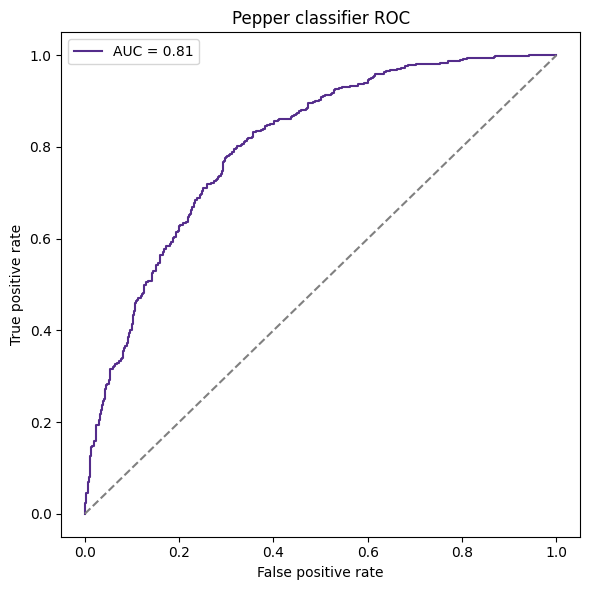

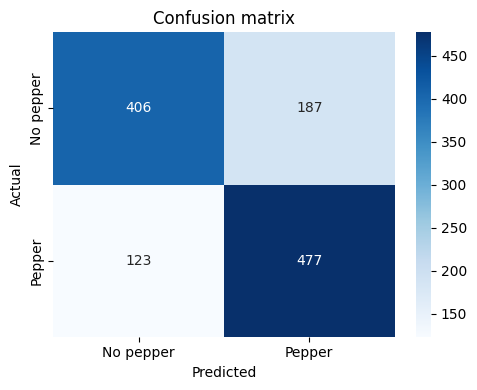

In [10]:
res, figs = questions.q10()
print(res)
show(figs, "q10_roc", "q10_confusion")

AUC ≈ 0.81 — average rating is the dominant signal.

## Q11 (bonus) — Do NY and NJ professors differ?

{'n_ny': 639, 'n_nj': 218, 'ny_mean': 3.9176838810641623, 'nj_mean': 4.011467889908257, 'mwu_p': 0.06205539017015309, 'ks_p': 0.020936298387905845, 'significant': False}


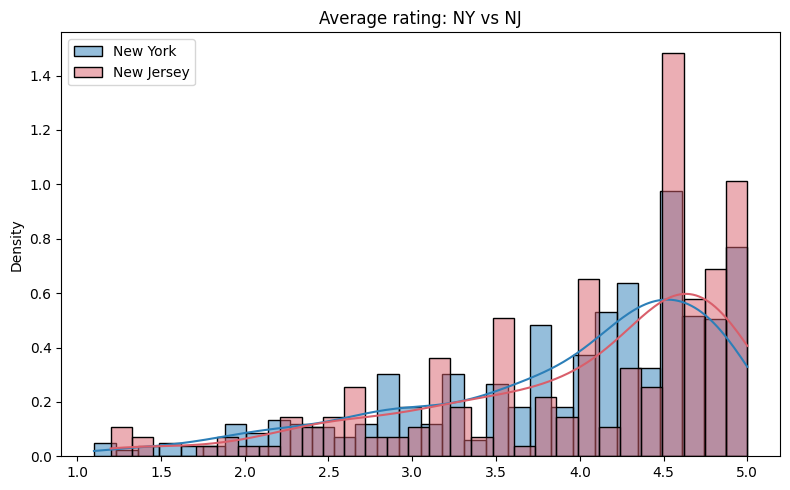

In [11]:
res, figs = questions.q11()
print(res)
show(figs, "q11_ny_vs_nj")

No significant difference at α = 0.005.